In [1]:
#Module1 : End Project
#As a culminating project, you'll be working with a dataset from ABC company,
#consisting of 458 rows and 9 columns. The company requires a comprehensive
#report detailing information about their employees across various teams. Your
#tasks include preprocessing the dataset, analyzing the data, and presenting your
#findings graphically

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

In [4]:
df=pd.read_excel("./drive/MyDrive/Data/ABC Company.xlsx")

In [5]:
df

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,2023-03-06 00:00:00,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,2023-01-06 00:00:00,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,2023-03-07 00:00:00,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0


In [6]:
import numpy as np
df['Height'] = np.random.randint(150, 181, size=len(df))
display(df.head())

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,154,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,172,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,165,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,164,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,168,231,NaN,5000000.0


In [7]:
team_distribution = df['Team'].value_counts()
total_employees = len(df)
percentage_split = (team_distribution / total_employees) * 100

distribution_df = pd.DataFrame({
    'Number of Employees': team_distribution,
    'Percentage (%)': percentage_split
})

display(distribution_df.sort_values(by='Number of Employees', ascending=False))

,Number of Employees,Percentage (%)
Team,,
New Orleans Pelicans,19,4.148472
Memphis Grizzlies,18,3.930131
Utah Jazz,16,3.493450
Milwaukee Bucks,16,3.493450
New York Knicks,16,3.493450
Boston Celtics,15,3.275109
Los Angeles Clippers,15,3.275109
Los Angeles Lakers,15,3.275109
Phoenix Suns,15,3.275109


In [ ]:
#Segregate employees based on their positions within the company.


In [8]:
position_distribution = df['Position'].value_counts()

display(position_distribution)

,count
Position,
SG,102
PF,100
PG,92
SF,85
C,79


In [ ]:
#Identify the predominant age group among employees.

In [9]:
predominant_age = df['Age'].value_counts().idxmax()
predominant_age_count = df['Age'].value_counts().max()

print(f"The predominant age among employees is {predominant_age} years, with {predominant_age_count} employees.")

The predominant age among employees is 24 years, with 47 employees.


In [ ]:
#Discover which team and position have the highest salary expenditure.


In [10]:
# Fill NaN salaries with 0 before summing to ensure accurate calculations
df['Salary'] = df['Salary'].fillna(0)

# Calculate salary expenditure by team
team_salary_expenditure = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)

# Calculate salary expenditure by position
position_salary_expenditure = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)

print("Team with the highest salary expenditure:")
display(team_salary_expenditure.head(1))

print("\nPosition with the highest salary expenditure:")
display(position_salary_expenditure.head(1))

Team with the highest salary expenditure:


,Salary
Team,
Cleveland Cavaliers,106988689.0



Position with the highest salary expenditure:


,Salary
Position,
C,466377332.0


In [ ]:
#Investigate if there's any correlation between age and salary, and
#represent it visually.


Correlation between Age and Salary: 0.21


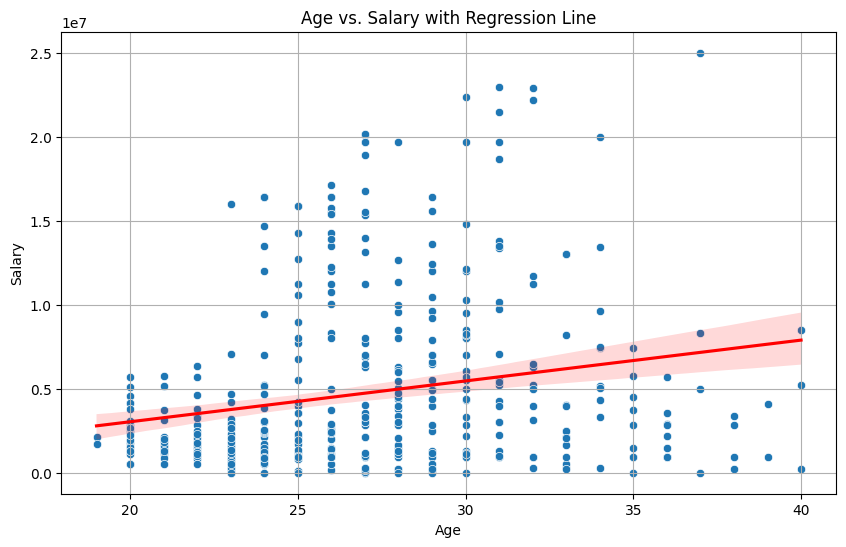

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation between Age and Salary
correlation = df['Age'].corr(df['Salary'])
print(f"Correlation between Age and Salary: {correlation:.2f}")

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Salary', data=df)
sns.regplot(x='Age', y='Salary', data=df, scatter=False, color='red') # Add a regression line
plt.title('Age vs. Salary with Regression Line')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)
plt.show()

The scatter plot above, along with the regression line, visually represents the relationship between 'Age' and 'Salary'. A positive correlation coefficient suggests that as age increases, salary tends to increase, while a negative coefficient suggests the opposite. A coefficient close to zero indicates a weak or no linear relationship. The regression line helps to identify the general trend in the data.

In [ ]:
# For each of the five analysis tasks above, create appropriate visualizations
#to present your findings effectively


### 1. Employee Distribution by Team

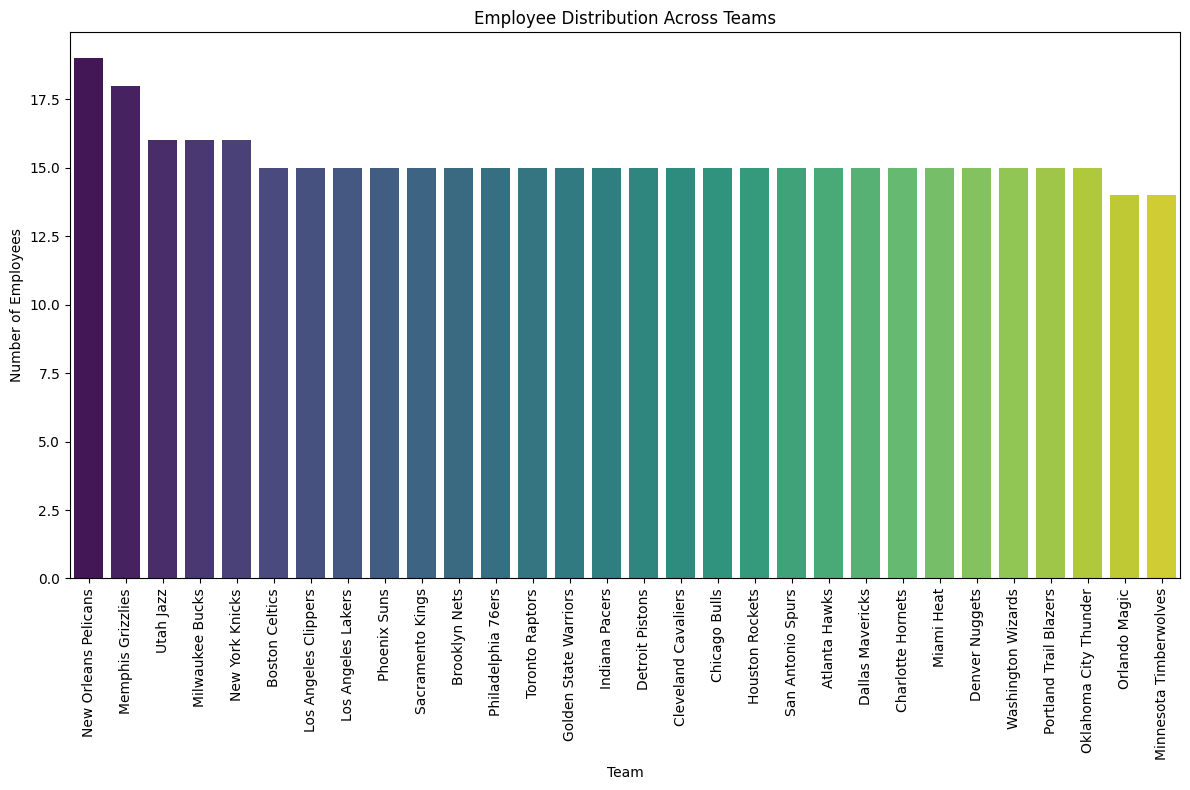

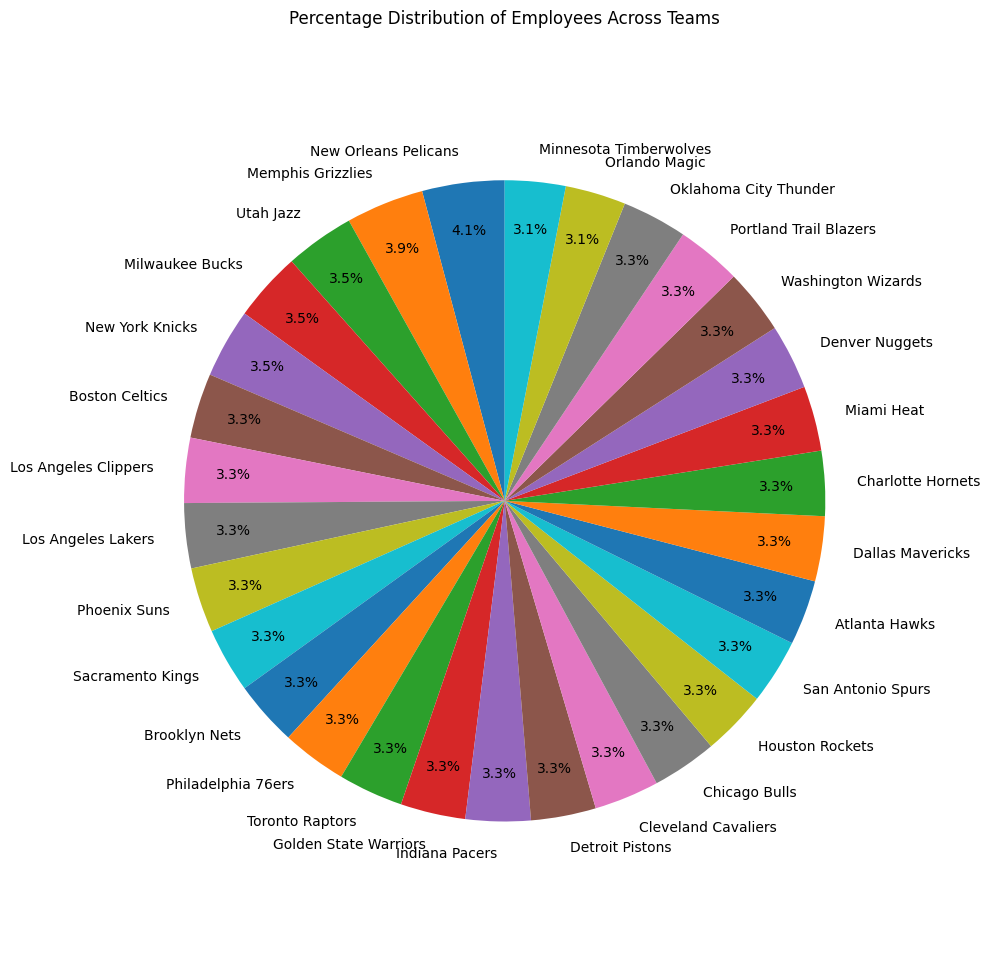

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=distribution_df.index, y='Number of Employees', data=distribution_df.sort_values(by='Number of Employees', ascending=False), palette='viridis', hue=distribution_df.index, legend=False)
plt.title('Employee Distribution Across Teams')
plt.xlabel('Team')
plt.ylabel('Number of Employees')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 10))
plt.pie(distribution_df['Percentage (%)'], labels=distribution_df.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Percentage Distribution of Employees Across Teams')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 2. Employee Segregation by Position

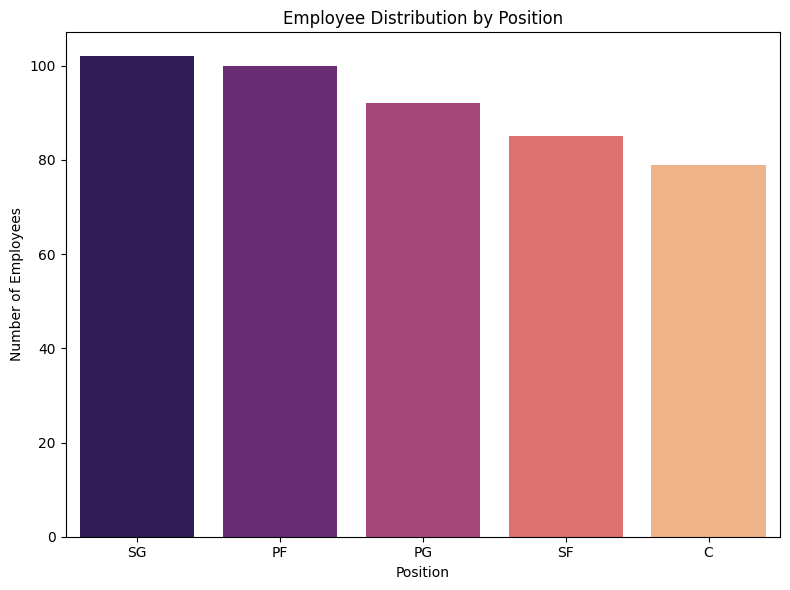

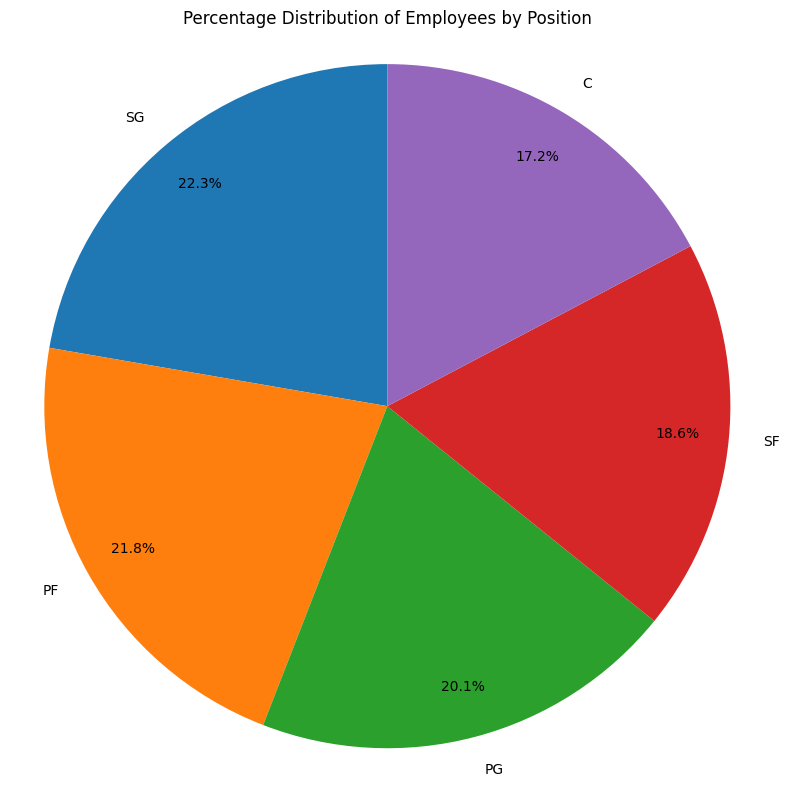

In [17]:
plt.figure(figsize=(8, 6))
sns.barplot(x=position_distribution.index, y=position_distribution.values, palette='magma', hue=position_distribution.index, legend=False)
plt.title('Employee Distribution by Position')
plt.xlabel('Position')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(position_distribution, labels=position_distribution.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Percentage Distribution of Employees by Position')
plt.axis('equal')
plt.tight_layout()
plt.show()

### 3. Predominant Age Group

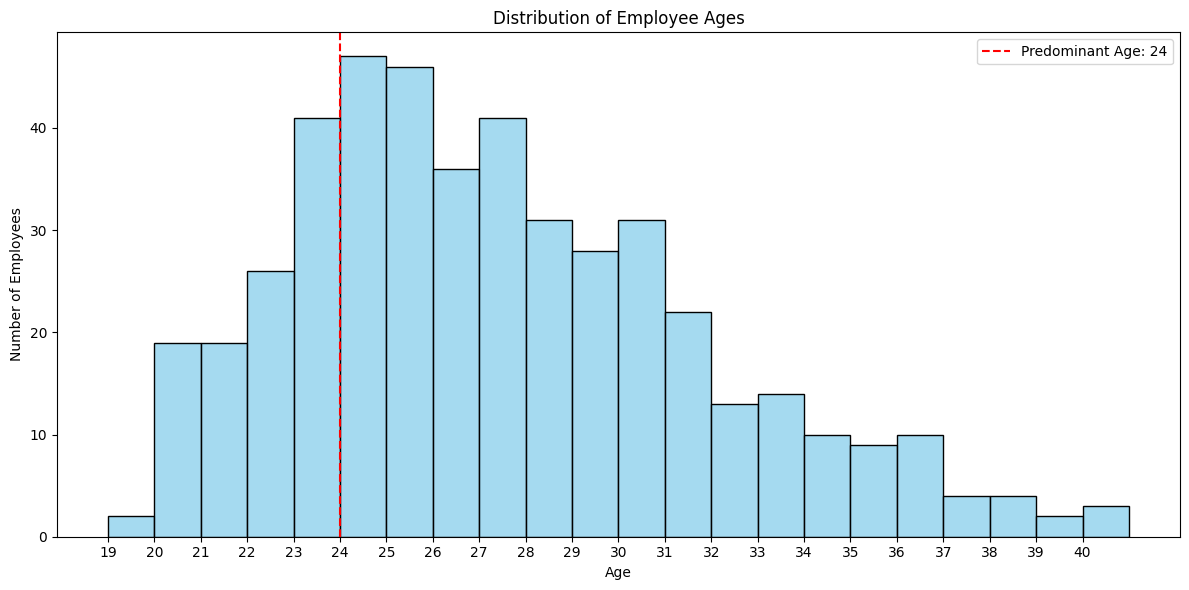

In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Age'], bins=range(df['Age'].min(), df['Age'].max() + 2), kde=False, color='skyblue')
plt.axvline(x=predominant_age, color='red', linestyle='--', label=f'Predominant Age: {predominant_age}')
plt.title('Distribution of Employee Ages')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.xticks(range(df['Age'].min(), df['Age'].max() + 1))
plt.legend()
plt.tight_layout()
plt.show()

### 4. Highest Salary Expenditure by Team and Position

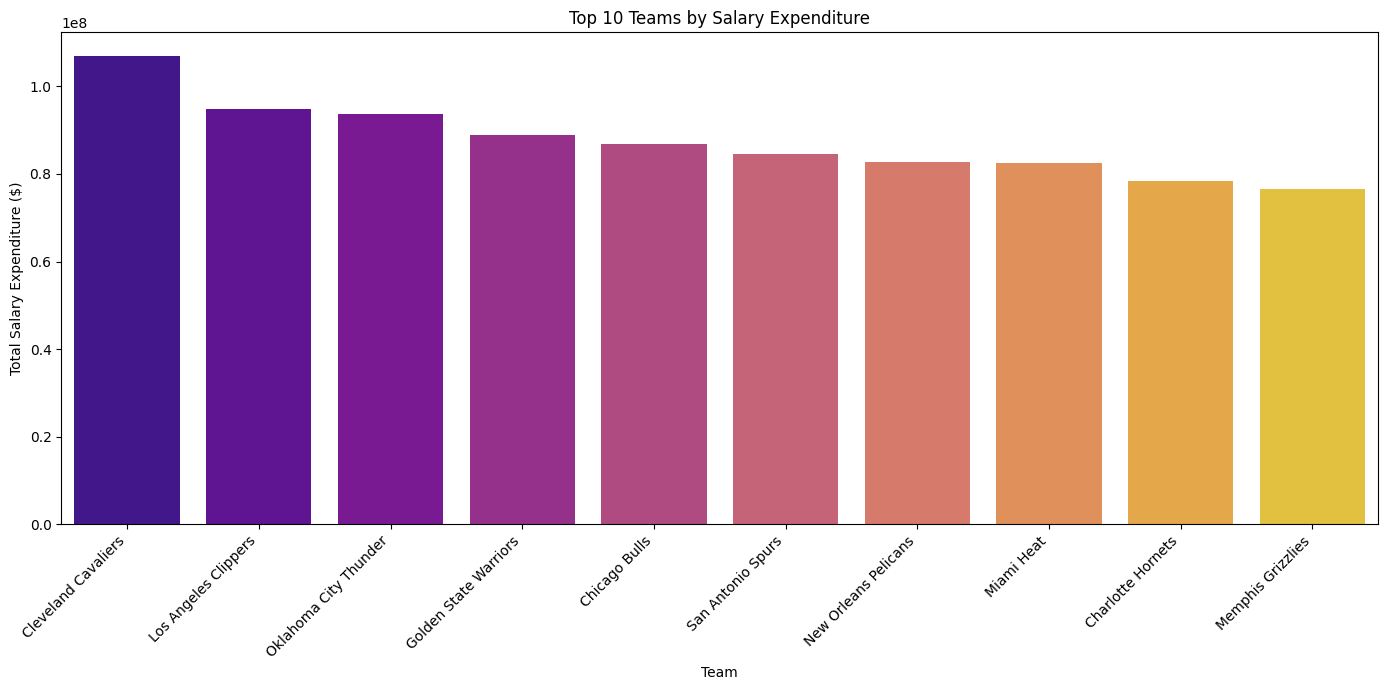

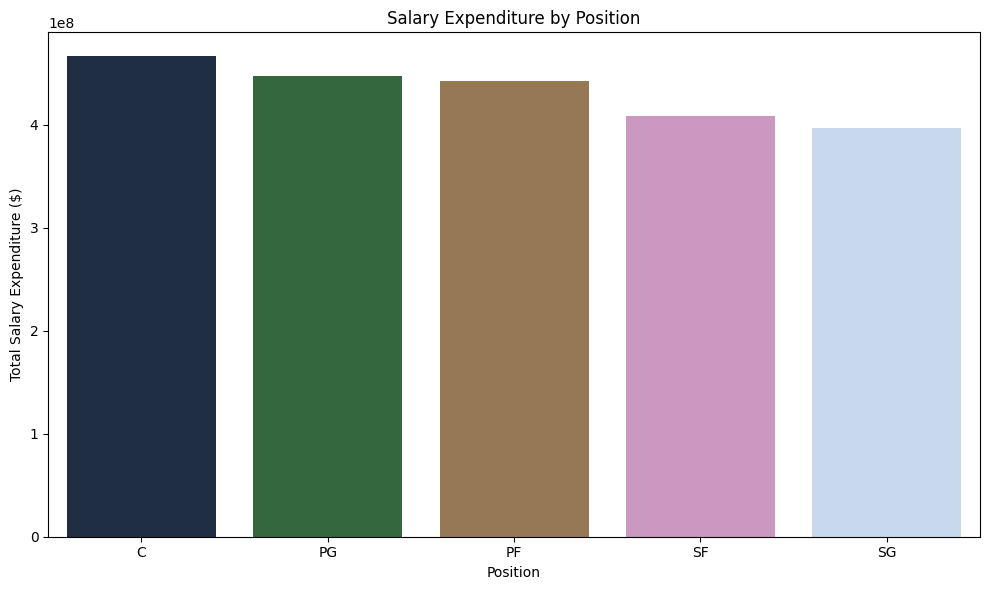

In [18]:
plt.figure(figsize=(14, 7))
sns.barplot(x=team_salary_expenditure.head(10).index, y=team_salary_expenditure.head(10).values, palette='plasma', hue=team_salary_expenditure.head(10).index, legend=False)
plt.title('Top 10 Teams by Salary Expenditure')
plt.xlabel('Team')
plt.ylabel('Total Salary Expenditure ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=position_salary_expenditure.index, y=position_salary_expenditure.values, palette='cubehelix', hue=position_salary_expenditure.index, legend=False)
plt.title('Salary Expenditure by Position')
plt.xlabel('Position')
plt.ylabel('Total Salary Expenditure ($)')
plt.tight_layout()
plt.show()